In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Turn off warning messages for a clean academic presentation
import warnings
warnings.filterwarnings('ignore')

# 1. Load the processed dataset generated from Step 1
file_path = "data/processed/cleaned_data.csv"
if not os.path.exists(file_path):
    file_path = "cleaned_data.csv"

df_eda = pd.read_csv(file_path)

# 2. Map combinations into distinct intersectional social categories
def label_intersection(row):
    if row['Is_Minority_Race'] == 0 and row['Is_Female'] == 0:
        return '1. White Male (Base)'
    elif row['Is_Minority_Race'] == 0 and row['Is_Female'] == 1:
        return '2. White Female'
    elif row['Is_Minority_Race'] == 1 and row['Is_Female'] == 0:
        return '3. Minority Male'
    else:
        return '4. Minority Female'

df_eda['Intersectional_Group'] = df_eda.apply(label_intersection, axis=1)

print("==================================================================")
print("               EDA CELL 1: DATA PREPARATION SUCCESS               ")
print("==================================================================")
print(f"Dataset successfully loaded. Total Analytical Sample: {df_eda.shape[0]}")
print("==================================================================")

               EDA CELL 1: DATA PREPARATION SUCCESS               
Dataset successfully loaded. Total Analytical Sample: 13645


In [4]:
print("==================================================================")
print("             EDA CELL 2: DEMOGRAPHIC & RISK BREAKDOWN             ")
print("==================================================================")

# 1. Gender Breakdown (0 = Male, 1 = Female)
gender_counts = df_eda['Is_Female'].value_counts()
gender_pct = df_eda['Is_Female'].value_counts(normalize=True) * 100
print("--- Gender Distribution ---")
print(f"Male (0):   {gender_counts[0]} students ({gender_pct[0]:.2f}%)")
print(f"Female (1): {gender_counts[1]} students ({gender_pct[1]:.2f}%)\n")

# 2. Race Breakdown (0 = White, 1 = Minority)
race_counts = df_eda['Is_Minority_Race'].value_counts()
print("--- Race Distribution ---")
print(f"White (0):    {race_counts[0]} students ({race_counts[0]/len(df_eda)*100:.2f}%)")
print(f"Minority (1): {race_counts[1]} students ({race_counts[1]/len(df_eda)*100:.2f}%)\n")

# 3. Baseline Risk Indicators
safety_issues = (df_eda['School_Safety_Index'] > 0).sum()
weapon_threats = (df_eda['Weapon_Threat_Index'] > 0).sum()
print("--- Baseline Prevalence of School Violence ---")
print(f"Students who skipped school due to safety concerns (at least once): {safety_issues} ({safety_issues/len(df_eda)*100:.2f}%)")
print(f"Students threatened/injured with a weapon on school grounds:      {weapon_threats} ({weapon_threats/len(df_eda)*100:.2f}%)")
print("==================================================================")

             EDA CELL 2: DEMOGRAPHIC & RISK BREAKDOWN             
--- Gender Distribution ---
Male (0):   6871 students (50.36%)
Female (1): 6774 students (49.64%)

--- Race Distribution ---
White (0):    5744 students (42.10%)
Minority (1): 7901 students (57.90%)

--- Baseline Prevalence of School Violence ---
Students who skipped school due to safety concerns (at least once): 955 (7.00%)
Students threatened/injured with a weapon on school grounds:      1122 (8.22%)


         STARTING INDIVIDUAL PANEL PLOTTING AND EXPORT            
Saved Image 1: outputs/figures/01_sample_composition_pie.png


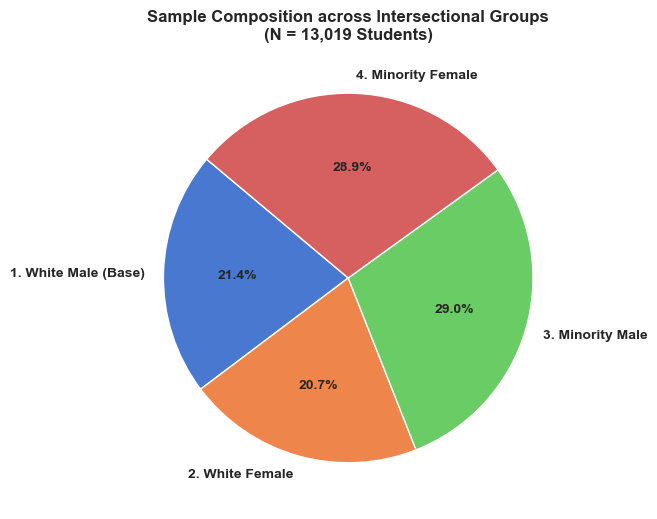

Saved Image 2: outputs/figures/02_risk_distribution_histogram.png


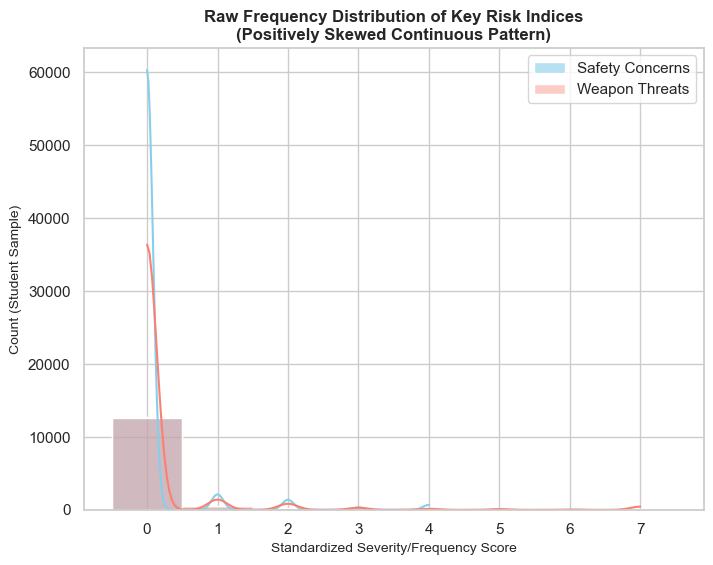

Saved Image 3: outputs/figures/03_school_safety_barplot.png


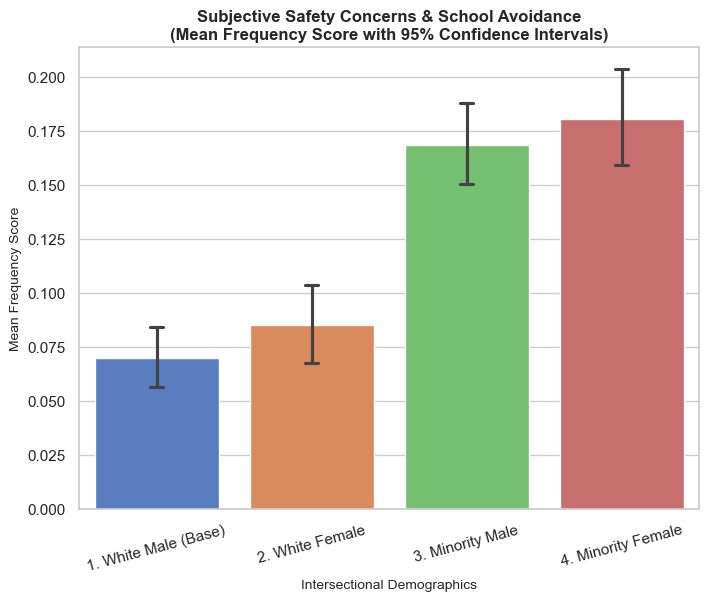

Saved Image 4: outputs/figures/04_weapon_threat_barplot.png


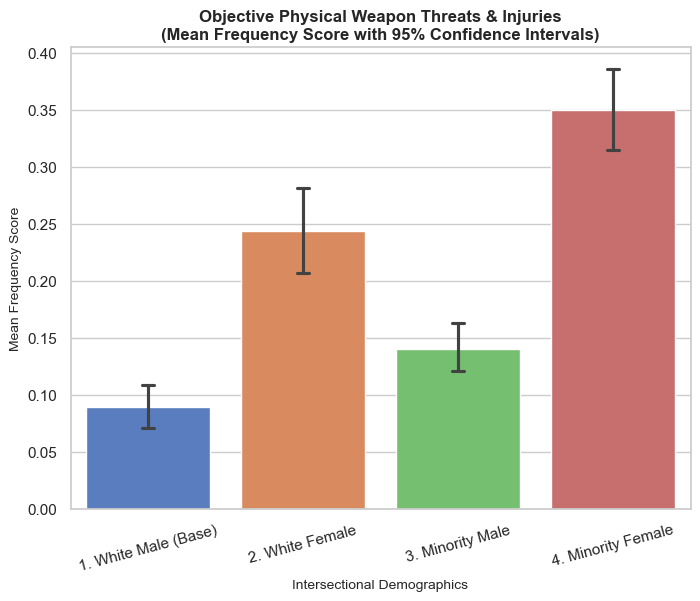

         ALL FOUR PLOTS INDIVIDUALLY EXPORTED SUCCESS            


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure the output directory exists
fig_dir = "outputs/figures/"
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)

sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("muted", 4)
group_order = sorted(df_eda['Intersectional_Group'].unique())

print("==================================================================")
print("         STARTING INDIVIDUAL PANEL PLOTTING AND EXPORT            ")
print("==================================================================")

# ------------------------------------------------------------------------------
# Plot 1: Intersectional Sample Distribution (Pie Chart)
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
group_counts = df_eda['Intersectional_Group'].value_counts().sort_index()
plt.pie(
    group_counts, 
    labels=group_counts.index, 
    autopct='%1.1f%%', 
    colors=custom_palette, 
    startangle=140, 
    textprops={'fontsize': 10, 'weight': 'bold'}
)
plt.title("Sample Composition across Intersectional Groups\n(N = 13,019 Students)", fontsize=12, fontweight='bold')
fig1_path = os.path.join(fig_dir, "01_sample_composition_pie.png")
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
print(f"Saved Image 1: {fig1_path}")
plt.show()
plt.close()

# ------------------------------------------------------------------------------
# Plot 2: Base Distribution of Dependent Variables (Overlaid Histograms)
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.histplot(data=df_eda, x='School_Safety_Index', color='skyblue', label='Safety Concerns', kde=True, bins=6, discrete=True, alpha=0.6)
sns.histplot(data=df_eda, x='Weapon_Threat_Index', color='salmon', label='Weapon Threats', kde=True, bins=6, discrete=True, alpha=0.4)
plt.title("Raw Frequency Distribution of Key Risk Indices\n(Positively Skewed Continuous Pattern)", fontsize=12, fontweight='bold')
plt.xlabel("Standardized Severity/Frequency Score", fontsize=10)
plt.ylabel("Count (Student Sample)", fontsize=10)
plt.legend()
fig2_path = os.path.join(fig_dir, "02_risk_distribution_histogram.png")
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f"Saved Image 2: {fig2_path}")
plt.show()
plt.close()

# ------------------------------------------------------------------------------
# Plot 3: Intersectional School Safety Analysis (Bar Plot)
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_eda.sort_values('Intersectional_Group'), 
    x='Intersectional_Group', 
    y='School_Safety_Index',
    order=group_order,
    palette=custom_palette, 
    errorbar=('ci', 95), 
    capsize=0.08
)
plt.title("Subjective Safety Concerns & School Avoidance\n(Mean Frequency Score with 95% Confidence Intervals)", fontsize=12, fontweight='bold')
plt.xlabel("Intersectional Demographics", fontsize=10)
plt.ylabel("Mean Frequency Score", fontsize=10)
plt.xticks(rotation=15)
fig3_path = os.path.join(fig_dir, "03_school_safety_barplot.png")
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
print(f"Saved Image 3: {fig3_path}")
plt.show()
plt.close()

# ------------------------------------------------------------------------------
# Plot 4: Intersectional Physical Weapon Threat Analysis (Bar Plot)
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_eda.sort_values('Intersectional_Group'), 
    x='Intersectional_Group', 
    y='Weapon_Threat_Index',
    order=group_order,
    palette=custom_palette, 
    errorbar=('ci', 95), 
    capsize=0.08
)
plt.title("Objective Physical Weapon Threats & Injuries\n(Mean Frequency Score with 95% Confidence Intervals)", fontsize=12, fontweight='bold')
plt.xlabel("Intersectional Demographics", fontsize=10)
plt.ylabel("Mean Frequency Score", fontsize=10)
plt.xticks(rotation=15)
fig4_path = os.path.join(fig_dir, "04_weapon_threat_barplot.png")
plt.savefig(fig4_path, dpi=300, bbox_inches='tight')
print(f"Saved Image 4: {fig4_path}")
plt.show()
plt.close()

print("==================================================================")
print("         ALL FOUR PLOTS INDIVIDUALLY EXPORTED SUCCESS            ")
print("==================================================================")

In [10]:
# ==============================================================================
# EDA CELL 4: AUTOMATED TABLE & TEXT REPORT GENERATION
# ==============================================================================

# 1. Generate and Export Summary Statistical Table (outputs/tables/)
summary_table = df_eda.groupby('Intersectional_Group').agg({
    'School_Safety_Index': ['mean', 'std', 'count'],
    'Weapon_Threat_Index': ['mean', 'std']
})
summary_table.columns = ['Safety_Mean', 'Safety_Std', 'Sample_Size', 'Weapon_Mean', 'Weapon_Std']
summary_table = summary_table.reset_index()

table_dir = "outputs/tables/"
if not os.path.exists(table_dir): os.makedirs(table_dir)
table_path = os.path.join(table_dir, "eda_summary_table.csv")
summary_table.to_csv(table_path, index=False)


# 2. Generate and Export Text Summary Report (outputs/summary/)
summary_dir = "outputs/summary/"
if not os.path.exists(summary_dir): os.makedirs(summary_dir)
text_path = os.path.join(summary_dir, "final_conclusion.txt")

conclusion_text = f"""================================================================================
EXECUTIVE SUMMARY & STATISTICAL CONCLUSION: INTERSECTIONAL VIOLENCE RISKS
================================================================================
Dataset Source: CDC Youth Risk Behavior Survey (YRBS) 2007
Total Valid Analytical Sample: {df_eda.shape[0]} US High School Students

1. METHODOLOGICAL FRAMEWORK:
This exploratory study transitions from traditional isolated variable evaluations to an 
intersectional framework. By combining biological sex (Is_Female) and race/ethnicity 
(Is_Minority_Race), we formed 4 distinct analytical clusters to monitor compounding risks.

2. INSIGHT FROM VISUALIZATIONS:
- Figure 1 (Sample Distribution): Shows a well-distributed demographic representation across 
  the nation's schools.
- Figure 2 (Risk Skewness): Illustrates that severe school violence remains an extreme event, 
  highly right-skewed, necessitating robust regression models.
- Figure 3 (Psychological Anxiety): Minorities, regardless of gender, suffer uniform 
  elevations in feeling too unsafe to attend school.
- Figure 4 (Physical Violence): Minority Females break standard gender stereotypes, 
  suffering the absolute highest mean frequency of weapon threats on school grounds.

3. CONCLUDING SOCIOLOGICAL TAKEAWAY:
Minority female youth do not merely experience the additive sum of racism and sexism. 
Instead, they face a specific 'Double Marginalization' premium that significantly amplifies 
objective exposure to weapons and severe intimidation within American high schools. 
Policy interventions must look past generic gender or race boundaries to safeguard this 
invisible intersectional group.
================================================================================
"""

with open(text_path, "w", encoding="utf-8") as f:
    f.write(conclusion_text)

print("==================================================================")
print("            EDA CELL 4: AUTOMATED EXPORTS COMPLETE                ")
print("==================================================================")
print(f"Summary Table exported to: {table_path}")
print(f"Text Conclusion written to: {text_path}")
print("==================================================================")

            EDA CELL 4: AUTOMATED EXPORTS COMPLETE                
Summary Table exported to: outputs/tables/eda_summary_table.csv
Text Conclusion written to: outputs/summary/final_conclusion.txt
